# 30b. Human-in-the-Loop

**Tier:** Production & Safety
**Estimated time:** 40 minutes
**Prerequisites:** 19, 28, 30
**Priority:** 🟡 Important — builds out the approval-gate defense notebook 30 names but only implements as a flat allow-list; mandatory before an agent gets a tool that can spend money, send messages, or delete data. *If skipped, revisit when:* your agent gains any tool with an irreversible real-world effect.
**Source material:** @sairahul1 — "How To Become an Agentic AI Engineer in 6 Months", Stage 7 (https://x.com/sairahul1/status/2074790798584062278)

## What You'll Learn
- Risk-tiering tool calls (low / medium / high) instead of one flat allow-list
- An approval gate wrapped around notebook 19's tool-execution step, with approve/reject/timeout outcomes
- An audit trail of every action, decision, and reason — queryable after the fact
- Pausing an agent mid-run and resuming it cleanly once a human has weighed in

## Why This Matters
Notebook 30's `execute_with_human_gate` asks one binary question: is this action name on the sensitive list, yes or no? That's a real defense, but it treats "delete a scratch file" and "transfer $50,000" identically, keeps no record of what was approved or why, and has no way to let an agent resume once a human actually responds. Production agents need risk that scales with consequence, a paper trail an auditor can read, and a run that survives a human taking five minutes — or five hours — to say yes.

## Full autonomy fails at the worst possible moment

A bug in a loop. A misread instruction. A tool call that seemed safe until it wasn't. Every one of notebook 30's defenses — least privilege, input/output guardrails, sandboxing — reduces the *chance* something goes wrong. None of them reduce the *cost* when something still does. A human-in-the-loop gate is the only defense in this repo whose job is specifically to make sure a false negative can't cause irreversible harm — not by catching the attack, but by refusing to let the consequence happen unwitnessed.

In [1]:
import os, json, pathlib, tempfile
from datetime import datetime, timezone
from enum import Enum
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

HAS_ANTHROPIC = bool(os.environ.get("ANTHROPIC_API_KEY"))
TEACH_MODEL = "claude-haiku-4-5-20251001"   # production default: claude-opus-4-8

if HAS_ANTHROPIC:
    import anthropic
    client = anthropic.Anthropic()
    print("Anthropic ready.")
else:
    client = None
    print("No ANTHROPIC_API_KEY — this notebook's demos run entirely on scripted/mock logic, so it still works fully offline.")

HITL_DIR = pathlib.Path(tempfile.mkdtemp(prefix="hitl30b_"))
print("Audit trail + pause-state persist to:", HITL_DIR)

Anthropic ready.
Audit trail + pause-state persist to: /var/folders/61/c6m8f0q93sxdlrrn5gmplfbr0000gn/T/hitl30b_xnr10qfh


## Risk tiering

Every tool call gets a `RiskLevel` before it runs. Low-risk actions auto-execute. Medium-risk actions execute but get logged. High-risk actions stop and wait for a human, no matter how confident the model was.

In [2]:
class RiskLevel(Enum):
    LOW = "low"       # auto-execute
    MEDIUM = "medium" # log, then auto-execute
    HIGH = "high"     # require human approval before executing

HIGH_RISK_ACTIONS = {"delete_file", "send_email", "charge_payment", "transfer_funds", "post_public"}
MEDIUM_RISK_ACTIONS = {"create_file", "update_record", "schedule_meeting"}

def assess_risk(action_name):
    if action_name in HIGH_RISK_ACTIONS:
        return RiskLevel.HIGH
    if action_name in MEDIUM_RISK_ACTIONS:
        return RiskLevel.MEDIUM
    return RiskLevel.LOW

for name in ["read_file", "schedule_meeting", "transfer_funds", "check_stock"]:
    print(f"{name:>16} -> {assess_risk(name).value}")

       read_file -> low
schedule_meeting -> medium
  transfer_funds -> high
     check_stock -> low


## A scripted human — headless-safe by design

The real interactive version of this gate calls `input()` and waits for a person to type `approve` or `reject`. That would hang `.claude/checks/notebooks.sh`, which must run unattended, so this notebook never calls `input()`. Instead, `ApprovalPolicy` pre-scripts how "the human" responds to each action — approve, reject, or time out — so the whole approval flow is exercised deterministically. Swap `ApprovalPolicy.decide` for a real `input()` prompt (or a Slack/email approval webhook) to make this interactive.

In [3]:
class ApprovalPolicy:
    # Maps action_name -> scripted human response, standing in for a real approval channel.
    def __init__(self, scripted_responses):
        self.scripted_responses = scripted_responses

    def decide(self, action_name, params):
        # In an interactive session this is where you'd block on input() or an approval webhook.
        # Here it looks up a pre-scripted outcome so the flow is fully deterministic and headless-safe.
        return self.scripted_responses.get(action_name, {"approved": False, "reason": "no response (timeout)"})

policy = ApprovalPolicy({
    "delete_file": {"approved": False, "reason": "human rejected — file still needed"},
    "send_email": {"approved": True, "reason": "human approved — content looked correct"},
    # "transfer_funds" deliberately has NO entry -> demonstrates the timeout/no-response path.
})

for action in ["delete_file", "send_email", "transfer_funds"]:
    print(action, "->", policy.decide(action, {}))

delete_file -> {'approved': False, 'reason': 'human rejected — file still needed'}
send_email -> {'approved': True, 'reason': 'human approved — content looked correct'}
transfer_funds -> {'approved': False, 'reason': 'no response (timeout)'}


## The audit trail

Every action gets logged regardless of risk tier or outcome — approved, rejected, auto-executed, or timed out. This is what turns "the agent did something weird last Tuesday" from a guess into a lookup.

In [4]:
AUDIT_LOG = HITL_DIR / "audit_log.jsonl"

def audit(action_name, params, risk, outcome, reason):
    entry = {
        "action": action_name,
        "params": params,
        "risk": risk.value,
        "outcome": outcome,
        "reason": reason,
        "at": datetime.now(timezone.utc).isoformat(),
    }
    with open(AUDIT_LOG, "a") as f:
        f.write(json.dumps(entry) + "\n")

def read_audit_log():
    if not AUDIT_LOG.exists():
        return []
    return [json.loads(line) for line in AUDIT_LOG.read_text().splitlines() if line]

print("Audit log ready at", AUDIT_LOG)

Audit log ready at /var/folders/61/c6m8f0q93sxdlrrn5gmplfbr0000gn/T/hitl30b_xnr10qfh/audit_log.jsonl


## Putting it together: the gated executor

One function every tool call goes through. Low risk executes immediately (and is still logged). Medium risk executes and is logged. High risk asks the (scripted) human first — approved calls execute, rejected or timed-out calls don't, and either way the decision is on the record.

In [5]:
TOOL_IMPLEMENTATIONS = {
    "read_file": lambda **kw: f"(simulated) read {kw.get('path')}",
    "schedule_meeting": lambda **kw: f"(simulated) scheduled meeting: {kw.get('topic')}",
    "delete_file": lambda **kw: f"(simulated) deleted {kw.get('path')}",
    "send_email": lambda **kw: f"(simulated) sent email to {kw.get('to')}",
    "transfer_funds": lambda **kw: f"(simulated) transferred ${kw.get('amount')} to {kw.get('to')}",
}

def execute_with_gate(action_name, params, policy):
    risk = assess_risk(action_name)

    if risk == RiskLevel.HIGH:
        decision = policy.decide(action_name, params)
        if not decision["approved"]:
            audit(action_name, params, risk, "blocked", decision["reason"])
            return {"executed": False, "reason": decision["reason"]}
        audit(action_name, params, risk, "executed_after_approval", decision["reason"])
    else:
        audit(action_name, params, risk, "executed", f"auto-executed at {risk.value} risk")

    result = TOOL_IMPLEMENTATIONS[action_name](**params)
    return {"executed": True, "result": result}

calls = [
    ("read_file", {"path": "handbook.pdf"}),
    ("schedule_meeting", {"topic": "quarterly review"}),
    ("delete_file", {"path": "product_notes.txt"}),
    ("send_email", {"to": "customer@example.com"}),
    ("transfer_funds", {"amount": 500, "to": "vendor-acct-9"}),
]

for action_name, params in calls:
    outcome = execute_with_gate(action_name, params, policy)
    print(f"{action_name:>16} -> {outcome}")

       read_file -> {'executed': True, 'result': '(simulated) read handbook.pdf'}
schedule_meeting -> {'executed': True, 'result': '(simulated) scheduled meeting: quarterly review'}
     delete_file -> {'executed': False, 'reason': 'human rejected — file still needed'}
      send_email -> {'executed': True, 'result': '(simulated) sent email to customer@example.com'}
  transfer_funds -> {'executed': False, 'reason': 'no response (timeout)'}


`delete_file` was rejected outright. `send_email` needed approval and got it. `transfer_funds` had no scripted response at all — the same shape a real timeout takes — and defaulted to blocked rather than silently proceeding. That "default to blocked, not default to allowed" choice is the entire point of a HIGH tier: an unanswered question about an irreversible action should never resolve in the agent's favor.

In [6]:
print(f"{'action':<16} {'risk':<8} {'outcome':<22} reason")
for entry in read_audit_log():
    print(f"{entry['action']:<16} {entry['risk']:<8} {entry['outcome']:<22} {entry['reason']}")

action           risk     outcome                reason
read_file        low      executed               auto-executed at low risk
schedule_meeting medium   executed               auto-executed at medium risk
delete_file      high     blocked                human rejected — file still needed
send_email       high     executed_after_approval human approved — content looked correct
transfer_funds   high     blocked                no response (timeout)


## Pause and resume

A HIGH-risk call that's still waiting on a human shouldn't mean the agent process has to stay alive (or block) until someone responds — that could be minutes or hours. Instead, the agent serializes its state (conversation so far, the pending action) to disk and exits. Whenever the human responds, a fresh process loads that state back and continues exactly where it left off.

In [7]:
PAUSE_STATE_FILE = HITL_DIR / "paused_run.json"

def pause_run(messages, pending_action, pending_params):
    state = {"messages": messages, "pending_action": pending_action, "pending_params": pending_params}
    PAUSE_STATE_FILE.write_text(json.dumps(state, indent=2))
    print(f"Paused. Waiting on human approval for: {pending_action}({pending_params})")

def resume_run(policy):
    if not PAUSE_STATE_FILE.exists():
        return {"resumed": False, "reason": "no paused run found"}
    state = json.loads(PAUSE_STATE_FILE.read_text())
    outcome = execute_with_gate(state["pending_action"], state["pending_params"], policy)
    if outcome["executed"]:
        state["messages"].append({"role": "user", "content": f"[tool result] {outcome['result']}"})
    else:
        state["messages"].append({"role": "user", "content": f"[tool blocked] {outcome['reason']}"})
    PAUSE_STATE_FILE.unlink()   # the pause is resolved either way — nothing left to resume
    return {"resumed": True, "messages": state["messages"]}

# The agent gets partway through a task, then hits a HIGH-risk action with no scripted answer
# yet — simulating "we haven't heard back from the human."
in_progress_messages = [
    {"role": "user", "content": "Refund the customer for their broken Helios X1."},
    {"role": "assistant", "content": "Found the order. Refunding $89.99 requires approval."},
]
pause_run(in_progress_messages, "transfer_funds", {"amount": 89.99, "to": "customer-refund"})

print()
print("...time passes, a different process entirely picks this back up...")
print()

# Now "the human" responds, and a resume call — which could run in a totally different
# process — picks the run back up from disk.
later_policy = ApprovalPolicy({"transfer_funds": {"approved": True, "reason": "manager approved refund"}})
result = resume_run(later_policy)
for m in result["messages"]:
    print(" -", m["role"], ":", m["content"])

Paused. Waiting on human approval for: transfer_funds({'amount': 89.99, 'to': 'customer-refund'})

...time passes, a different process entirely picks this back up...

 - user : Refund the customer for their broken Helios X1.
 - assistant : Found the order. Refunding $89.99 requires approval.
 - user : [tool result] (simulated) transferred $89.99 to customer-refund


Nothing about `resume_run` depends on being the same Python process that called `pause_run` — it only depends on `PAUSE_STATE_FILE` existing. That's what makes this safe to pause for however long a human actually takes: the agent isn't blocked, it's simply not running, and its full context is sitting on disk waiting to be picked back up.

## Where this goes next

Project **P4**'s multi-agent system tracks a *team-wide* tool-call budget in shared state so any agent's routing decision sees the whole team's usage, not just its own — the same principle as this notebook's shared audit log, scaled from "one gate, one log" to "many agents, one budget." The risk-tiering + gate pattern here is what you'd wrap around any of P4's higher-risk tool calls before giving that system real-world tools.

## Visualizing the gate

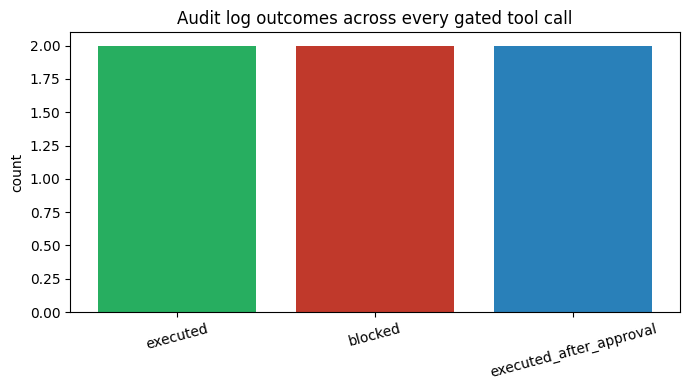

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
from collections import Counter

entries = read_audit_log()
outcome_counts = Counter(e["outcome"] for e in entries)

fig, ax = plt.subplots(figsize=(7, 4))
labels = list(outcome_counts.keys())
values = [outcome_counts[k] for k in labels]
colors = {"executed": "#27ae60", "executed_after_approval": "#2980b9", "blocked": "#c0392b"}
ax.bar(labels, values, color=[colors.get(l, "#7f8c8d") for l in labels])
ax.set_ylabel("count")
ax.set_title("Audit log outcomes across every gated tool call")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

*Every call left a trace — auto-executed, executed after approval, or blocked. None of them vanished silently, which is the entire value of an audit trail: an incident review starts from a log, not a guess.*

## Exercises

In [9]:
# Exercise 1 (Warm-up): Reclassify a tool's risk tier
# Task: Move "schedule_meeting" from MEDIUM_RISK_ACTIONS into HIGH_RISK_ACTIONS, re-run
#       assess_risk on it, and call execute_with_gate with a policy that has no scripted
#       response for it. Confirm it now blocks by default instead of auto-executing.
# Hint: You'll need to add "schedule_meeting" to HIGH_RISK_ACTIONS and remove it from
#       MEDIUM_RISK_ACTIONS so assess_risk's HIGH check matches first.

# YOUR CODE HERE

In [10]:
# Exercise 2 (Apply): Add a timeout with default-deny
# Task: Modify ApprovalPolicy.decide so that if no scripted response exists for an action, it
#       returns {"approved": False, "reason": "timeout after N seconds, defaulting to deny"}
#       instead of the current generic "no response (timeout)" message. Confirm transfer_funds
#       (which has no scripted entry above) now returns your new message.
# Hint: This is a one-line change to the .get(...) default value in decide().

# YOUR CODE HERE

In [11]:
# Exercise 3 (Extend): Add an approval gate to a P3-style research agent
# Task: Sketch (in comments or code) how you'd wrap execute_with_gate around a write_file tool
#       in a notebook-19/P3-style research agent, so that writing a report to disk always
#       requires human approval before the file is actually written.
# Hint: write_file only needs ONE entry added to HIGH_RISK_ACTIONS — the gate mechanism itself
#       doesn't change at all, which is the whole point of building it as one reusable function.

# YOUR CODE HERE

<details>
<summary>Show solutions</summary>

```python
# Exercise 1
MEDIUM_RISK_ACTIONS.discard("schedule_meeting")
HIGH_RISK_ACTIONS.add("schedule_meeting")
print(assess_risk("schedule_meeting"))   # RiskLevel.HIGH

no_response_policy = ApprovalPolicy({})   # nothing scripted for schedule_meeting
print(execute_with_gate("schedule_meeting", {"topic": "board sync"}, no_response_policy))
# {'executed': False, 'reason': 'no response (timeout)'} — blocked by default, exactly like
# transfer_funds was above, once schedule_meeting became a HIGH-risk action.

# Exercise 2
class ApprovalPolicyWithTimeout(ApprovalPolicy):
    def decide(self, action_name, params, timeout_seconds=300):
        return self.scripted_responses.get(
            action_name,
            {"approved": False, "reason": f"timeout after {timeout_seconds} seconds, defaulting to deny"},
        )

policy2 = ApprovalPolicyWithTimeout({"send_email": {"approved": True, "reason": "ok"}})
print(policy2.decide("transfer_funds", {}))
# {'approved': False, 'reason': 'timeout after 300 seconds, defaulting to deny'}

# Exercise 3
# Sketch:
# HIGH_RISK_ACTIONS.add("write_file")
# TOOL_IMPLEMENTATIONS["write_file"] = lambda **kw: f"(simulated) wrote {kw['path']}"
#
# def run_research_agent_with_gate(goal, policy, max_steps=8):
#     ...
#     for block in resp.content:
#         if block.type == "tool_use" and block.name == "write_file":
#             outcome = execute_with_gate("write_file", block.input, policy)   # gated
#         elif block.type == "tool_use":
#             outcome = {"executed": True, "result": TOOL_IMPLEMENTATIONS[block.name](**block.input)}
# Every OTHER tool (web_search, read_file) stays auto-executing; only write_file's real-world
# side effect now waits on approval, because only write_file was added to HIGH_RISK_ACTIONS.
```
</details>

## Key Takeaways
- Risk tiering (LOW auto-execute / MEDIUM log-and-execute / HIGH require approval) replaces notebook 30's flat allow-list with consequence-scaled gating.
- An unscripted or unanswered HIGH-risk decision should default to blocked, never to allowed — a timeout is not the same as a "yes."
- Every gated call gets logged regardless of outcome; the audit trail is what turns incident review into a lookup instead of a guess.
- Pausing an agent means serializing its state to disk, not blocking a process — resuming only requires that state file to exist, not the original process to still be running.
- This is infrastructure any tool with a real-world, hard-to-reverse effect should sit behind — the gate function itself never changes, only which actions are routed through it.

## What's Next
Notebook **31 — MCP** picks the tool-integration thread back up: once tools are shared across agents and hosts via a common protocol, this notebook's gate is exactly what you'd wrap around any MCP tool whose effects can't be undone.